# 대시보드 — 경영진용 / MD용

- **경영진용**: 비즈니스 현황, 추천 시스템 임팩트
- **MD용**: 상품 현황, 고객 세그먼트 × 추천

### 데이터 출처 (04_GNN_성능평가 실행 후)

| 파일 | 설명 |
|------|------|
| `Final_Dashboard_Master.csv` | 군집·거래·상품 메타 통합 (Tableau 연동용) |
| `gnn_customer_clusters.csv` | 고객별 KMeans 군집 라벨 |
| `gnn_metrics.json` | Recall@K, NDCG@K 메트릭 |
| `model_comparison_recall_ndcg.csv` | GNN vs 인기도 베이스라인 비교 |


In [ ]:
import pandas as pd
import numpy as np
import os

PARQUET_DIR = '../Data Folder/H&M dataset/H&m parquet dataset'
transactions = pd.read_parquet(f'{PARQUET_DIR}/transactions.parquet')
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])
transactions['article_id'] = transactions['article_id'].astype(str)

# price 컬럼 → price_eur (H&M 원본 price는 이미 EUR)
if 'price_eur' not in transactions.columns and 'price' in transactions.columns:
    transactions['price_eur'] = transactions['price']  # 590 곱하기 X

transactions['year_month'] = transactions['t_dat'].dt.to_period('M')

customers = pd.read_parquet(f'{PARQUET_DIR}/customers.parquet')
articles = pd.read_parquet(f'{PARQUET_DIR}/articles.parquet')
articles['article_id'] = articles['article_id'].astype(str)

art_cols = [c for c in ['article_id','prod_name','product_group_name','index_group_name','colour_group_name'] if c in articles.columns]
art_csv = articles[art_cols].copy()

print(f'거래: {len(transactions):,} | 고객: {len(customers):,} | 상품: {len(articles):,}')
transactions.head(2)

거래: 31,097,423 | 고객: 1,356,119 | 상품: 105,542


,t_dat,customer_id,article_id,price,sales_channel_id,price_eur,days_from_latest,time_weight,covid_period,year_month
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0663713001,0.050831,2,29.99,733,2.447587e-11,Pre-COVID,2018-09
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0541518023,0.030492,2,17.99,733,2.447587e-11,Pre-COVID,2018-09


In [2]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import json

_fp = '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'
if os.path.exists(_fp):
    fm.fontManager.addfont(_fp)
    plt.rcParams['font.family'] = fm.FontProperties(fname=_fp).get_name()
else:
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

EXPORT_PATH = '../Data Folder/dashboard'
os.makedirs(EXPORT_PATH, exist_ok=True)

GNN_CLUSTER_PATH = '../Data Folder/gnn_customer_clusters.csv'
GNN_METRICS_PATH = '../Data Folder/gnn_metrics.json'

if os.path.exists(GNN_CLUSTER_PATH):
    gnn_clusters = pd.read_csv(GNN_CLUSTER_PATH)
else:
    np.random.seed(42)
    unique_customers = transactions['customer_id'].unique()
    gnn_clusters = pd.DataFrame({'customer_id': unique_customers, 'gnn_style_cluster': np.random.randint(0, 4, len(unique_customers))})
    persona_map = {0:'Summer/Beach', 1:'Casual Denim', 2:'Smart/Discount', 3:'Essential'}
    gnn_clusters['gnn_persona'] = gnn_clusters['gnn_style_cluster'].map(persona_map)

if os.path.exists(GNN_METRICS_PATH):
    with open(GNN_METRICS_PATH) as f: gnn_m = json.load(f)
    pop_recall, pop_ndcg = gnn_m.get('recall_popularity', 0.0076), gnn_m.get('ndcg_popularity', 0.0054)
    gnn_recall, gnn_ndcg = gnn_m.get('recall_gnn', 0.0152), gnn_m.get('ndcg_gnn', 0.0108)
else:
    pop_recall, pop_ndcg = 0.0076, 0.0054
    gnn_recall, gnn_ndcg = 0.0152, 0.0108


## 대시보드 A — 경영진용

### [A-1] 경영진 공통 전처리


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

ref_date = transactions['t_dat'].max() + pd.Timedelta(days=1)
rfm = transactions.groupby('customer_id').agg(recency_days=('t_dat', lambda x: (ref_date - x.max()).days), frequency=('t_dat', 'count'), monetary=('price_eur', 'sum')).reset_index()
rfm.columns = ['customer_id', 'recency_days', 'frequency', 'monetary_eur']
rfm_scaled = StandardScaler().fit_transform(rfm[['recency_days', 'frequency', 'monetary_eur']])
rfm['rfm_cluster'] = KMeans(n_clusters=4, random_state=42).fit_predict(rfm_scaled)
cluster_rank = rfm.groupby('rfm_cluster')['monetary_eur'].mean().sort_values(ascending=False)
rank_to_label = {cluster_rank.index[0]: 'VIP 고객', cluster_rank.index[1]: '충성 고객', cluster_rank.index[2]: '잠재 고객', cluster_rank.index[3]: '이탈 위험'}
rfm['rfm_persona'] = rfm['rfm_cluster'].map(rank_to_label)
ltv = rfm.set_index('customer_id')['monetary_eur'].to_dict()
vip_ltv, churn_ltv, vip_pct, vip_sales_pct = 2961, 43, 2.9, 41

first_purchase = transactions.groupby('customer_id')['t_dat'].min().reset_index()
first_purchase.columns = ['customer_id', 'first_month']
first_purchase['first_month'] = first_purchase['first_month'].dt.to_period('M')
tx_with_cohort = transactions.merge(first_purchase, on='customer_id')
tx_with_cohort['tx_month'] = tx_with_cohort['t_dat'].dt.to_period('M')
cohort_size = tx_with_cohort.groupby('first_month')['customer_id'].nunique()
cohort_matrix = tx_with_cohort.pivot_table(index='first_month', columns='tx_month', values='customer_id', aggfunc='nunique').fillna(0)
cohort_pct = cohort_matrix.div(cohort_matrix.iloc[:, 0], axis=0)
cohort_pct.index = cohort_pct.index.astype(str)
cohort_pct.columns = cohort_pct.columns.astype(str)


### [A-2] TAB 1 — 비즈니스 현황 차트


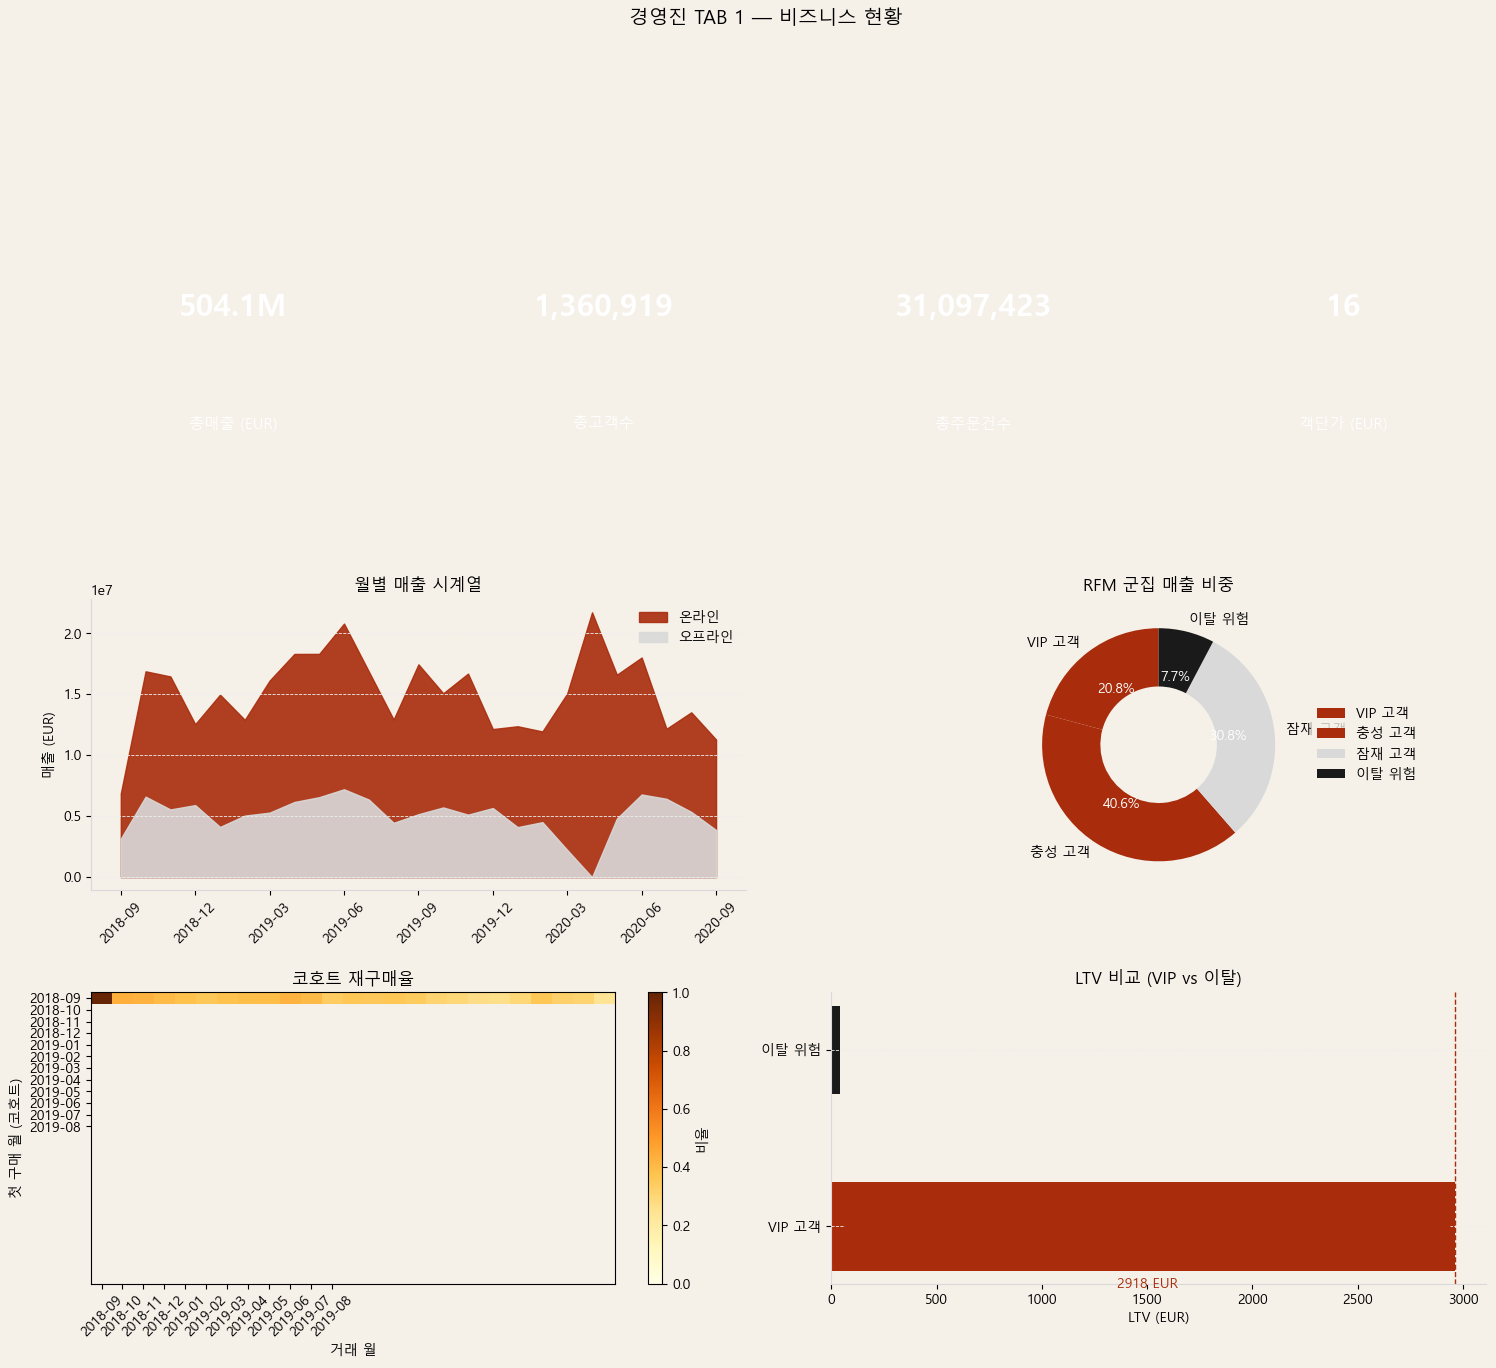

In [4]:
import matplotlib.gridspec as gridspec
if not os.path.exists(_fp): plt.rcParams['font.family'] = 'Malgun Gothic'
else: fm.fontManager.addfont(_fp); plt.rcParams['font.family'] = fm.FontProperties(fname=_fp).get_name()
plt.rcParams['axes.unicode_minus'] = False
fig = plt.figure(figsize=(18, 14), facecolor='#F5F0E8')
gs = fig.add_gridspec(3, 4, hspace=0.35, wspace=0.3)
total_revenue = transactions['price_eur'].sum(); n_customers = transactions['customer_id'].nunique(); n_orders = len(transactions); atv = total_revenue / n_orders if n_orders else 0
for i, (val, label, sub) in enumerate([(total_revenue, f'{total_revenue/1e6:.1f}M', '총매출 (EUR)'), (n_customers, f'{n_customers:,}', '총고객수'), (n_orders, f'{n_orders:,}', '총주문건수'), (atv, f'{atv:.0f}', '객단가 (EUR)')]):
    ax = fig.add_subplot(gs[0, i]); ax.set_facecolor('#a92c0c'); ax.axis('off')
    ax.text(0.5, 0.65, label, ha='center', va='center', fontsize=22, color='white', fontweight='bold')
    ax.text(0.5, 0.25, sub, ha='center', va='center', fontsize=11, color='white')
ax1 = fig.add_subplot(gs[1, 0:2]); ax1.set_facecolor('#F5F0E8')
monthly = transactions.groupby('year_month')['price_eur'].sum()
online = transactions[transactions['sales_channel_id']==2].groupby('year_month')['price_eur'].sum()
offline = transactions[transactions['sales_channel_id']==1].groupby('year_month')['price_eur'].sum()
x = range(len(monthly))
ax1.fill_between(x, online.reindex(monthly.index).fillna(0).values, color='#a92c0c', alpha=0.9, label='온라인')
ax1.fill_between(x, offline.reindex(monthly.index).fillna(0).values, color='#D9D9D9', alpha=0.9, label='오프라인')
ax1.set_xticks(x[::3]); ax1.set_xticklabels([str(monthly.index[i]) for i in range(0, len(monthly), 3)], rotation=45)
ax1.set_ylabel('매출 (EUR)'); ax1.legend(facecolor='#F5F0E8', edgecolor='none')
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False); ax1.spines['left'].set_color('#D9D9D9'); ax1.spines['bottom'].set_color('#D9D9D9')
ax1.yaxis.grid(True, color='#EEEEEE', linestyle='--', linewidth=0.6); ax1.set_title('월별 매출 시계열')
ax2 = fig.add_subplot(gs[1, 2:4]); ax2.set_facecolor('#F5F0E8')
rfm_sales = transactions.merge(rfm[['customer_id','rfm_persona']], on='customer_id').groupby('rfm_persona')['price_eur'].sum()
order_persona = ['VIP 고객','충성 고객','잠재 고객','이탈 위험']; rfm_sales = rfm_sales.reindex(order_persona).fillna(0)
colors_donut = ['#a92c0c','#a92c0c','#D9D9D9','#1A1A1A']
wedges, texts, autotexts = ax2.pie(rfm_sales, labels=rfm_sales.index, autopct='%1.1f%%', colors=colors_donut, startangle=90, wedgeprops=dict(width=0.5), textprops=dict(size=10))
for t in autotexts: t.set_color('white')
ax2.set_title('RFM 군집 매출 비중'); ax2.legend(facecolor='#F5F0E8', edgecolor='none', loc='center left', bbox_to_anchor=(1, 0.5))
ax3 = fig.add_subplot(gs[2, 0:2]); ax3.set_facecolor('#F5F0E8')
arr = cohort_pct.values; im = ax3.imshow(arr, aspect='auto', cmap='YlOrBr', vmin=0, vmax=1)
ax3.set_xticks(range(min(12, arr.shape[1]))); ax3.set_xticklabels(list(cohort_pct.columns)[:12], rotation=45)
ax3.set_yticks(range(min(12, arr.shape[0]))); ax3.set_yticklabels(list(cohort_pct.index)[:12])
ax3.set_xlabel('거래 월'); ax3.set_ylabel('첫 구매 월 (코호트)'); ax3.set_title('코호트 재구매율')
plt.colorbar(im, ax=ax3, label='비율')
ax4 = fig.add_subplot(gs[2, 2:4]); ax4.set_facecolor('#F5F0E8')
ax4.barh(['VIP 고객'], [vip_ltv], color='#a92c0c', height=0.5); ax4.barh(['이탈 위험'], [churn_ltv], color='#1A1A1A', height=0.5)
ax4.axvline(vip_ltv, color='#a92c0c', linestyle='--', linewidth=1); ax4.set_xlabel('LTV (EUR)'); ax4.set_title('LTV 비교 (VIP vs 이탈)')
ax4.spines['top'].set_visible(False); ax4.spines['right'].set_visible(False); ax4.spines['left'].set_color('#D9D9D9'); ax4.spines['bottom'].set_color('#D9D9D9')
ax4.yaxis.grid(True, color='#EEEEEE', linestyle='--', linewidth=0.6)
diff = vip_ltv - churn_ltv; ax4.annotate('', xy=(vip_ltv, 0), xytext=(churn_ltv, 0), arrowprops=dict(arrowstyle='<->', color='#a92c0c', lw=2))
ax4.text((vip_ltv+churn_ltv)/2, -0.35, f'{diff:.0f} EUR', ha='center', fontsize=10, color='#a92c0c')
plt.suptitle('경영진 TAB 1 — 비즈니스 현황', fontsize=14, y=1.02)
plt.savefig(f'{EXPORT_PATH}/exec_tab1_business.png', dpi=150, bbox_inches='tight', facecolor='#F5F0E8'); plt.show()


### [A-3] TAB 2 — 추천 시스템 임팩트 차트


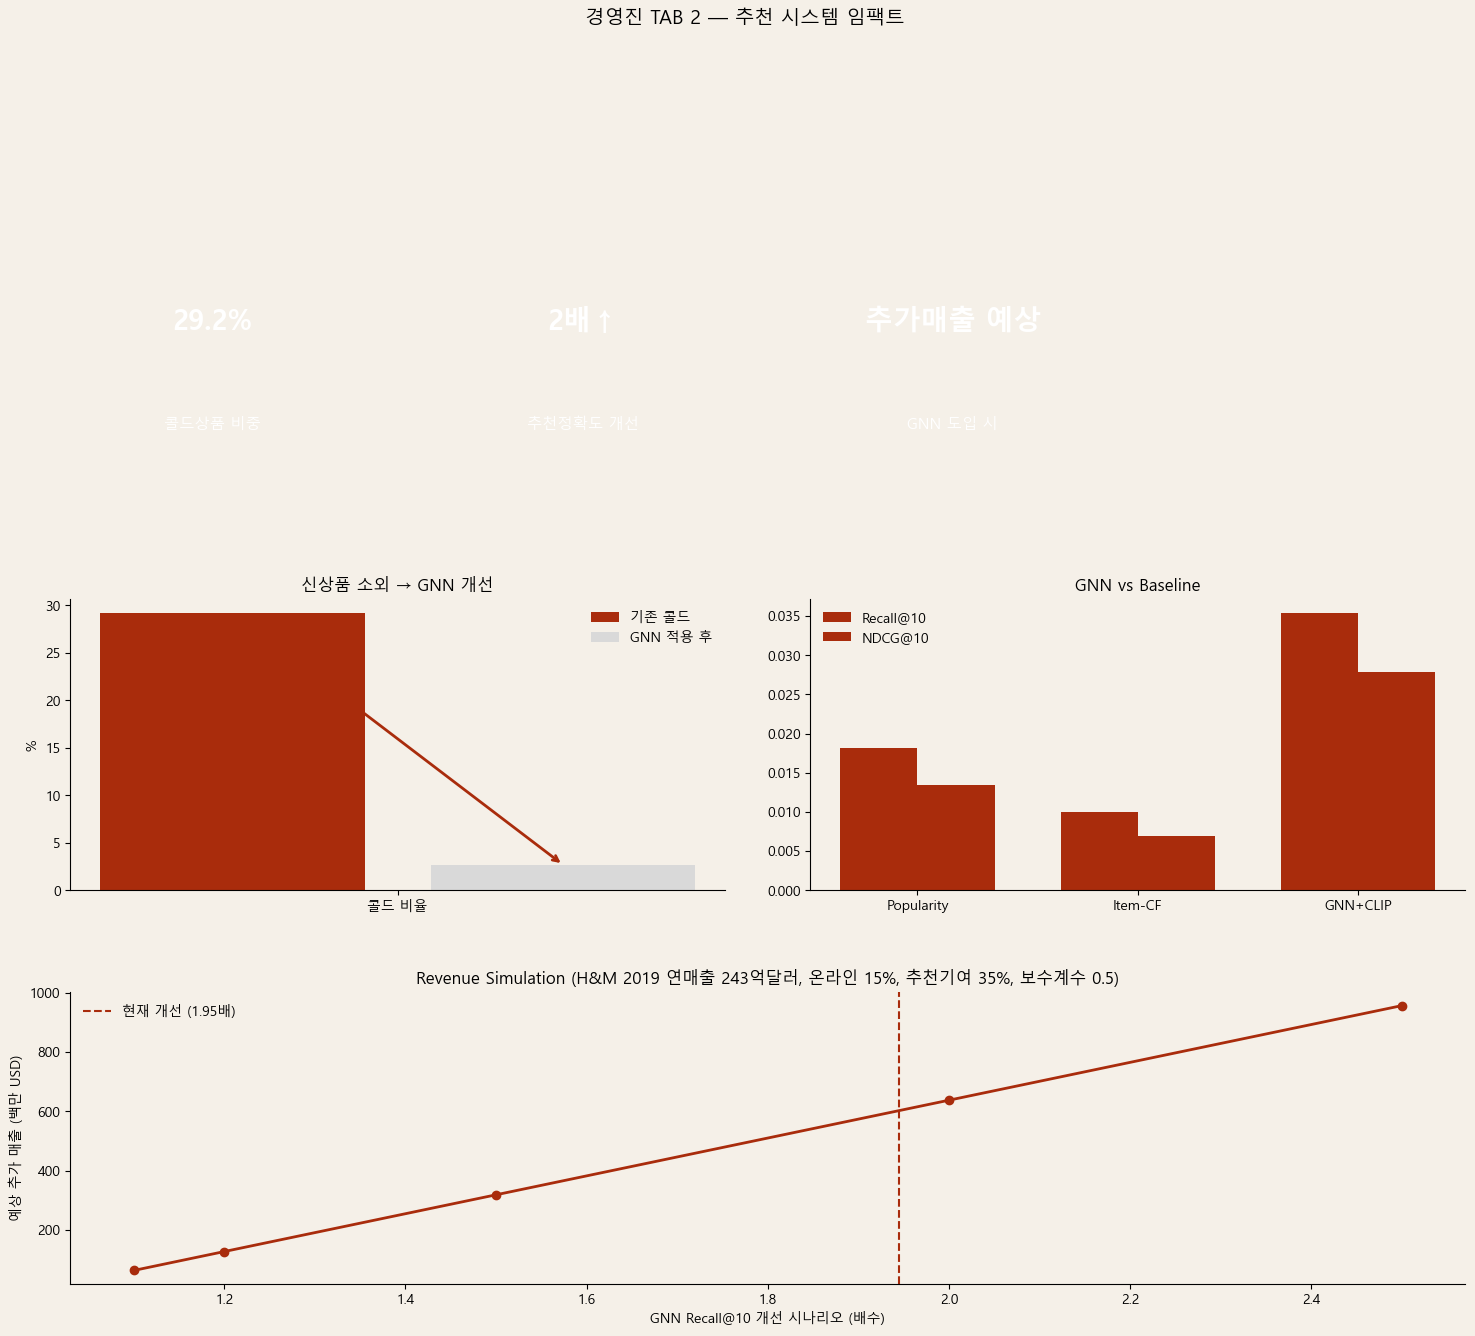

In [5]:
fig = plt.figure(figsize=(18, 14), facecolor='#F5F0E8')
gs = fig.add_gridspec(3, 4, hspace=0.35, wspace=0.3)
cold_pct_before, cold_pct_after = 29.2, 2.7
for i, (label, sub) in enumerate([(f'{cold_pct_before}%', '콜드상품 비중'), ('2배↑', '추천정확도 개선'), ('추가매출 예상', 'GNN 도입 시')]):
    ax = fig.add_subplot(gs[0, i]); ax.set_facecolor('#a92c0c'); ax.axis('off')
    ax.text(0.5, 0.6, label, ha='center', va='center', fontsize=20, color='white', fontweight='bold')
    ax.text(0.5, 0.25, sub, ha='center', va='center', fontsize=11, color='white')
ax1 = fig.add_subplot(gs[1, 0:2]); ax1.set_facecolor('#F5F0E8')
ax1.bar([0], [cold_pct_before], color='#a92c0c', width=0.4, label='기존 콜드'); ax1.bar([0.5], [cold_pct_after], color='#D9D9D9', width=0.4, label='GNN 적용 후')
ax1.set_xticks([0.25]); ax1.set_xticklabels(['콜드 비율']); ax1.set_ylabel('%'); ax1.legend(facecolor='#F5F0E8', edgecolor='none')
ax1.annotate('', xy=(0.5, cold_pct_after), xytext=(0, cold_pct_before), arrowprops=dict(arrowstyle='->', color='#a92c0c', lw=2))
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False); ax1.set_title('신상품 소외 → GNN 개선')
ax2 = fig.add_subplot(gs[1, 2:4]); ax2.set_facecolor('#F5F0E8')
models = ['Popularity', 'Item-CF', 'GNN+CLIP']; recall_vals = [pop_recall, 0.01, gnn_recall]; ndcg_vals = [pop_ndcg, 0.007, gnn_ndcg]
x = np.arange(len(models)); w = 0.35
ax2.bar(x - w/2, recall_vals, w, label='Recall@10', color='#a92c0c'); ax2.bar(x + w/2, ndcg_vals, w, label='NDCG@10', color='#a92c0c')
ax2.set_xticks(x); ax2.set_xticklabels(models); ax2.legend(facecolor='#F5F0E8', edgecolor='none')
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False); ax2.set_title('GNN vs Baseline')
ax3 = fig.add_subplot(gs[2, :]); ax3.set_facecolor('#F5F0E8')
scenarios = np.array([1.1, 1.2, 1.5, 2.0, 2.5])
base_rev_billion = 24.3 * 0.15 * 0.35 * 0.5
revenue_m = base_rev_billion * 1000 * (scenarios - 1)
ax3.plot(scenarios, revenue_m, 'o-', color='#a92c0c', linewidth=2)
current_ratio = gnn_recall / pop_recall if pop_recall else 2.0
ax3.axvline(current_ratio, color='#a92c0c', linestyle='--', linewidth=1.5, label=f'현재 개선 ({current_ratio:.2f}배)')
ax3.legend(facecolor='#F5F0E8', edgecolor='none')
ax3.set_xlabel('GNN Recall@10 개선 시나리오 (배수)'); ax3.set_ylabel('예상 추가 매출 (백만 USD)')
ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False); ax3.set_title('Revenue Simulation (H&M 2019 연매출 243억달러, 온라인 15%, 추천기여 35%, 보수계수 0.5)')
plt.suptitle('경영진 TAB 2 — 추천 시스템 임팩트', fontsize=14, y=1.02)
plt.savefig(f'{EXPORT_PATH}/exec_tab2_impact.png', dpi=150, bbox_inches='tight', facecolor='#F5F0E8'); plt.show()


### [A-4] 경영진 CSV 저장


In [7]:
# gnn_persona 컬럼 없으면 자동 생성
if 'gnn_persona' not in gnn_clusters.columns:
    persona_map = {0:'Summer/Beach', 1:'Casual Denim', 2:'Smart/Discount', 3:'Essential'}
    gnn_clusters['gnn_persona'] = gnn_clusters['cluster_label'].map(persona_map)

kpi_master = pd.DataFrame([
    {'metric':'총매출_EUR','value':transactions['price_eur'].sum()},
    {'metric':'총고객수','value':transactions['customer_id'].nunique()},
    {'metric':'총주문건수','value':len(transactions)},
    {'metric':'객단가_EUR','value':transactions['price_eur'].sum()/len(transactions)},
    {'metric':'VIP_LTV_EUR','value':vip_ltv},
    {'metric':'이탈_LTV_EUR','value':churn_ltv},
    {'metric':'VIP_비율_pct','value':vip_pct},
    {'metric':'VIP_매출비중_pct','value':vip_sales_pct},
    {'metric':'recall_popularity','value':pop_recall},
    {'metric':'ndcg_popularity','value':pop_ndcg},
    {'metric':'recall_gnn','value':gnn_recall},
    {'metric':'ndcg_gnn','value':gnn_ndcg},
])
kpi_master.to_csv(f'{EXPORT_PATH}/kpi_master.csv', index=False, encoding='utf-8-sig')

cus_stats = rfm.merge(gnn_clusters, on='customer_id', how='left')
cus_stats['activity_level'] = pd.cut(cus_stats['recency_days'], bins=[-1,30,90,9999], labels=['Active','Lapsing','Churned'])
if 'age' in customers.columns:
    cus_stats = cus_stats.merge(customers[['customer_id','age']], on='customer_id', how='left')
else:
    cus_stats['age'] = np.nan
ch_ratio = (transactions[transactions['sales_channel_id']==2].groupby('customer_id').size() / transactions.groupby('customer_id').size()).reindex(cus_stats['customer_id']).fillna(0)
cus_stats['channel_preference'] = ch_ratio.map(lambda x: 'Online' if x > 0.6 else ('Offline' if x < 0.4 else 'Mixed')).values

dim_customers = cus_stats[['customer_id','rfm_persona','gnn_persona','activity_level','recency_days','age','channel_preference']].copy()
dim_customers.to_csv(f'{EXPORT_PATH}/customers.csv', index=False, encoding='utf-8-sig')
print('kpi_master.csv, customers.csv 저장 완료')


kpi_master.csv, customers.csv 저장 완료


## 대시보드 B — MD용

### [B-1] MD 공통 전처리


In [ ]:
first_sale = transactions.groupby('article_id')['t_dat'].min().reset_index(); first_sale.columns = ['article_id', 'first_sale_date']
item_stats = transactions.groupby('article_id').agg(total_sales=('customer_id','count'), unique_buyers=('customer_id','nunique'), online_ratio=('sales_channel_id', lambda x: round((x==2).mean(), 3)), avg_price_eur=('price_eur','mean')).reset_index()
item_stats = item_stats.merge(art_csv, on='article_id', how='left')
n = len(item_stats); item_stats = item_stats.sort_values('total_sales', ascending=False).reset_index(drop=True)
item_stats['rank_pct'] = (item_stats.index + 1) / n * 100
item_stats['pareto_tier'] = 'Long-tail'; item_stats.loc[item_stats['rank_pct'] <= 5, 'pareto_tier'] = 'Star'; item_stats.loc[(item_stats['rank_pct'] > 5) & (item_stats['rank_pct'] <= 20), 'pareto_tier'] = 'Core'
item_stats = item_stats.merge(first_sale, on='article_id')
last_sale = transactions.groupby('article_id')['t_dat'].max().reset_index(); last_sale.columns = ['article_id', 'last_sale_date']
item_stats = item_stats.merge(last_sale, on='article_id')
item_stats['item_lifetime_days'] = (item_stats['last_sale_date'] - item_stats['first_sale_date']).dt.days
df_cw = transactions.merge(first_sale, on='article_id')
df_cw['days_since_first'] = (df_cw['t_dat'] - df_cw['first_sale_date']).dt.days
first_4w = df_cw[df_cw['days_since_first'] <= 28].groupby('article_id').size().reindex(item_stats['article_id']).fillna(0)
item_stats['is_cold'] = (first_4w <= 5).values
print('item_stats 행 수:', len(item_stats), '| 콜드 상품 수:', item_stats['is_cold'].sum())


item_stats 행 수: 104400 | 콜드 상품 수: 30844


### [B-2] TAB 1 — 상품 현황 차트


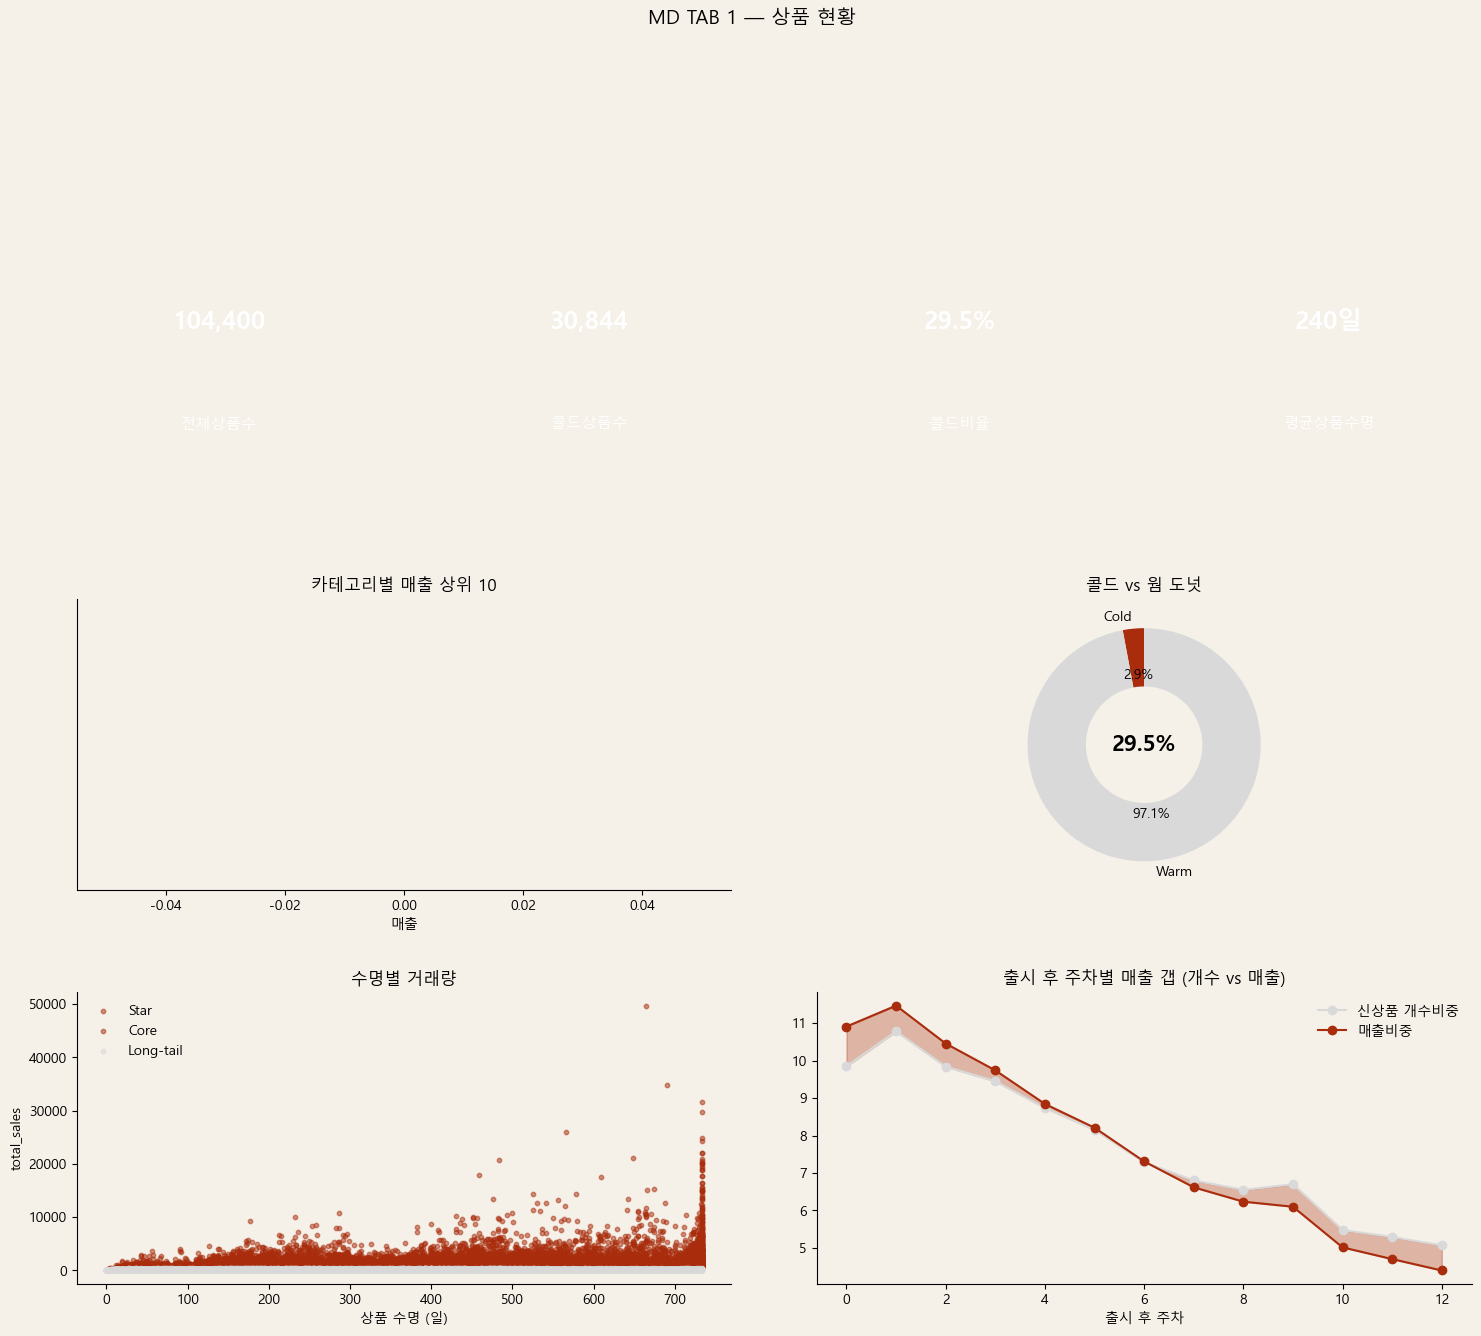

In [ ]:
fig = plt.figure(figsize=(18, 14), facecolor='#F5F0E8'); gs = fig.add_gridspec(3, 4, hspace=0.35, wspace=0.3)
n_items = len(item_stats); n_cold = item_stats['is_cold'].sum(); cold_ratio = round(n_cold / n_items * 100, 1) if n_items else 0; avg_life = item_stats['item_lifetime_days'].mean()
for i, (label, sub) in enumerate([(f'{n_items:,}', '전체상품수'), (f'{n_cold:,}', '콜드상품수'), (f'{cold_ratio}%', '콜드비율'), (f'{avg_life:.0f}일', '평균상품수명')]):
    ax = fig.add_subplot(gs[0, i]); ax.set_facecolor('#a92c0c'); ax.axis('off'); ax.text(0.5, 0.6, label, ha='center', va='center', fontsize=18, color='white', fontweight='bold'); ax.text(0.5, 0.25, sub, ha='center', va='center', fontsize=11, color='white')
ax1 = fig.add_subplot(gs[1, 0:2]); ax1.set_facecolor('#F5F0E8')
cat_sales = item_stats.groupby('product_group_name')['total_sales'].sum().nlargest(10).sort_values()
ax1.barh(range(len(cat_sales)), cat_sales.values, color='#a92c0c', alpha=0.85); ax1.set_yticks(range(len(cat_sales))); ax1.set_yticklabels(cat_sales.index)
ax1.set_xlabel('매출'); ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False); ax1.set_title('카테고리별 매출 상위 10')
ax2 = fig.add_subplot(gs[1, 2:4]); ax2.set_facecolor('#F5F0E8')
cold_sum = item_stats[item_stats['is_cold']]['total_sales'].sum(); warm_sum = item_stats[~item_stats['is_cold']]['total_sales'].sum()
ax2.pie([cold_sum, warm_sum], labels=['Cold', 'Warm'], autopct='%1.1f%%', colors=['#a92c0c', '#D9D9D9'], startangle=90, wedgeprops=dict(width=0.5))
ax2.text(0, 0, f'{cold_ratio}%', ha='center', va='center', fontsize=16, fontweight='bold'); ax2.set_title('콜드 vs 웜 도넛')
ax3 = fig.add_subplot(gs[2, 0:2]); ax3.set_facecolor('#F5F0E8')
for tier, c in [('Star', '#a92c0c'), ('Core', '#a92c0c'), ('Long-tail', '#D9D9D9')]:
    d = item_stats[item_stats['pareto_tier']==tier]; ax3.scatter(d['item_lifetime_days'], d['total_sales'], alpha=0.5, s=10, c=c, label=tier)
ax3.set_xlabel('상품 수명 (일)'); ax3.set_ylabel('total_sales'); ax3.legend(facecolor='#F5F0E8', edgecolor='none'); ax3.set_title('수명별 거래량'); ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)
ax4 = fig.add_subplot(gs[2, 2:4]); ax4.set_facecolor('#F5F0E8')
trx_with_first = transactions.merge(first_sale, on='article_id'); trx_with_first['week'] = (trx_with_first['t_dat'] - trx_with_first['first_sale_date']).dt.days // 7
week_df = trx_with_first[trx_with_first['week'] <= 12]
week_sales = week_df.groupby('week')['price_eur'].sum(); week_cnt = week_df.groupby('week').size()
sales_pct = week_sales.values / week_sales.sum() * 100; count_pct = week_cnt.values / week_cnt.sum() * 100
weeks = week_sales.index.values
ax4.plot(weeks, count_pct, 'o-', color='#D9D9D9', label='신상품 개수비중')
ax4.plot(weeks, sales_pct, 'o-', color='#a92c0c', label='매출비중')
ax4.fill_between(weeks, count_pct, sales_pct, alpha=0.3, color='#a92c0c')
ax4.set_xlabel('출시 후 주차'); ax4.legend(facecolor='#F5F0E8', edgecolor='none'); ax4.set_title('출시 후 주차별 매출 갭 (개수 vs 매출)'); ax4.spines['top'].set_visible(False); ax4.spines['right'].set_visible(False)
plt.suptitle('MD TAB 1 — 상품 현황', fontsize=14, y=1.02); plt.savefig(f'{EXPORT_PATH}/md_tab1_products.png', dpi=150, bbox_inches='tight', facecolor='#F5F0E8'); plt.show()


### [B-3] TAB 2 — 고객 세그먼트 × 추천 차트


C:\Users\urina\AppData\Local\Temp\ipykernel_19880\3843070537.py:17: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = ax3.imshow(heat.values / 1000, aspect='auto', cmap='YlOrBr'); ax3.set_xticks([0,1]); ax3.set_xticklabels(heat.columns); ax3.set_yticks(range(len(heat))); ax3.set_yticklabels(heat.index, fontsize=8); ax3.set_title('카테고리 × 채널 (거래건수 천)'); plt.colorbar(im, ax=ax3)
C:\Users\urina\AppData\Local\Temp\ipykernel_19880\3843070537.py:17: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im = ax3.imshow(heat.values / 1000, aspect='auto', cmap='YlOrBr'); ax3.set_xticks([0,1]); ax3.set_xticklabels(heat.columns); ax3.set_yticks(range(len(heat))); ax3.set_yticklabels(heat.index, fontsize=8); ax3.set_title('카테고리 × 채널 (거래건수 천)'); plt.colorbar(im, ax=ax3)


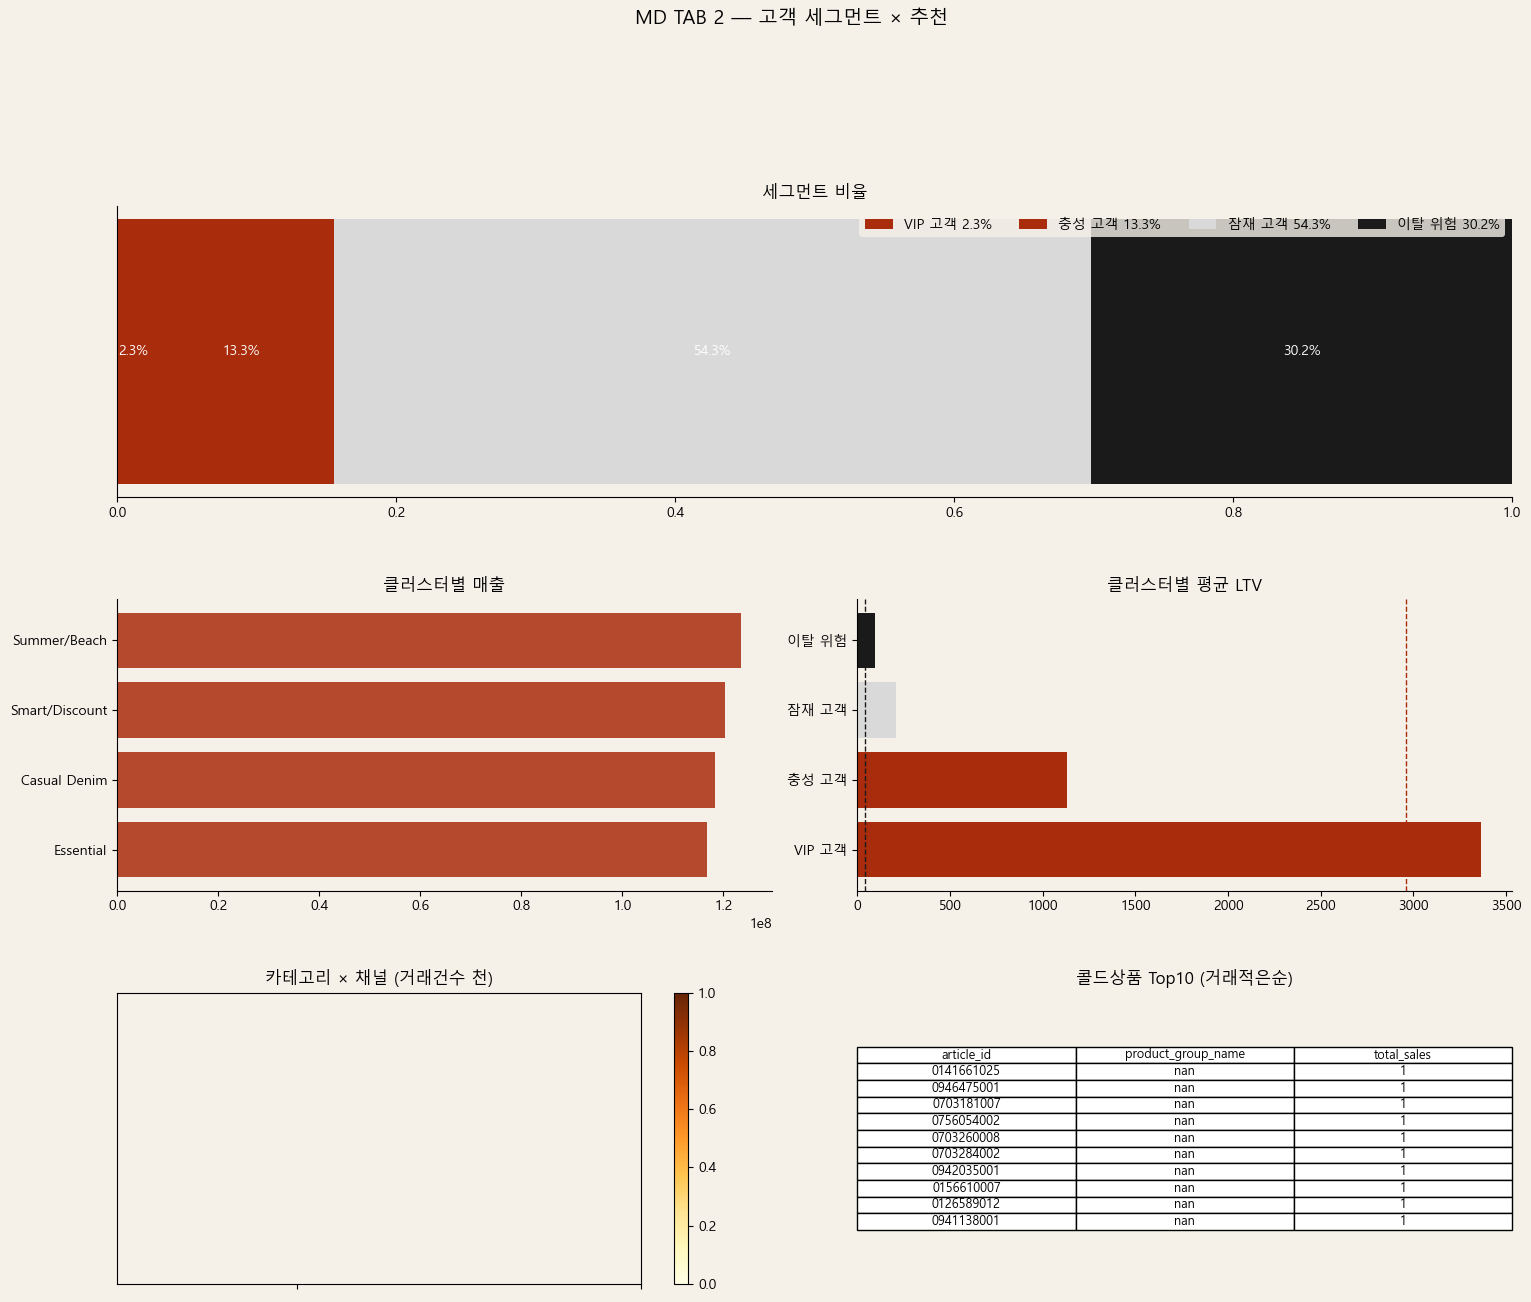

In [ ]:
fig = plt.figure(figsize=(18, 14), facecolor='#F5F0E8'); gs = fig.add_gridspec(3, 4, hspace=0.35, wspace=0.3)
persona_pct = rfm['rfm_persona'].value_counts(normalize=True).reindex(['VIP 고객','충성 고객','잠재 고객','이탈 위험']).fillna(0)
ax0 = fig.add_subplot(gs[0, :]); ax0.set_facecolor('#F5F0E8')
left = 0; colors_s = ['#a92c0c','#a92c0c','#D9D9D9','#1A1A1A']
for i, (p, v) in enumerate(persona_pct.items()):
    ax0.barh(0, v, left=left, height=0.5, color=colors_s[i], label=f'{p} {v*100:.1f}%'); ax0.text(left + v/2, 0, f'{v*100:.1f}%', ha='center', va='center', color='white', fontsize=10); left += v
ax0.set_xlim(0, 1); ax0.set_yticks([]); ax0.legend(facecolor='#F5F0E8', edgecolor='none', ncol=4); ax0.set_title('세그먼트 비율'); ax0.spines['top'].set_visible(False); ax0.spines['right'].set_visible(False)
ax1 = fig.add_subplot(gs[1, 0:2]); ax1.set_facecolor('#F5F0E8')
gnn_sales = transactions.merge(gnn_clusters, on='customer_id').groupby('gnn_persona')['price_eur'].sum()
gnn_sales = gnn_sales.sort_values(ascending=True); ax1.barh(gnn_sales.index, gnn_sales.values, color='#a92c0c', alpha=0.85); ax1.set_title('클러스터별 매출'); ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)
ax2 = fig.add_subplot(gs[1, 2:4]); ax2.set_facecolor('#F5F0E8')
ltv_by_persona = rfm.groupby('rfm_persona')['monetary_eur'].mean().reindex(['VIP 고객','충성 고객','잠재 고객','이탈 위험'])
ax2.barh(ltv_by_persona.index, ltv_by_persona.values, color=colors_s); ax2.axvline(vip_ltv, color='#a92c0c', linestyle='--', linewidth=1); ax2.axvline(churn_ltv, color='#1A1A1A', linestyle='--', linewidth=1); ax2.set_title('클러스터별 평균 LTV'); ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
ax3 = fig.add_subplot(gs[2, 0:2]); ax3.set_facecolor('#F5F0E8')
trx_ch = transactions.copy(); trx_ch['channel'] = trx_ch['sales_channel_id'].map({1:'Offline', 2:'Online'}); trx_ch = trx_ch.merge(item_stats[['article_id','product_group_name']], on='article_id')
heat = trx_ch.groupby(['product_group_name','channel']).size().unstack(fill_value=0); heat = heat.reindex(item_stats.groupby('product_group_name')['total_sales'].sum().nlargest(10).index).fillna(0)
im = ax3.imshow(heat.values / 1000, aspect='auto', cmap='YlOrBr'); ax3.set_xticks([0,1]); ax3.set_xticklabels(heat.columns); ax3.set_yticks(range(len(heat))); ax3.set_yticklabels(heat.index, fontsize=8); ax3.set_title('카테고리 × 채널 (거래건수 천)'); plt.colorbar(im, ax=ax3)
ax4 = fig.add_subplot(gs[2, 2:4]); ax4.axis('off')
cold_top = item_stats[item_stats['is_cold']].nsmallest(10, 'total_sales')[['article_id','product_group_name','total_sales']]
cell_text = cold_top.astype(str).values.tolist()
tbl = ax4.table(cellText=cell_text, colLabels=cold_top.columns.tolist(), loc='center', cellLoc='center'); tbl.auto_set_font_size(False); tbl.set_fontsize(9); ax4.set_title('콜드상품 Top10 (거래적은순)')
plt.suptitle('MD TAB 2 — 고객 세그먼트 × 추천', fontsize=14, y=1.02); plt.savefig(f'{EXPORT_PATH}/md_tab2_segment.png', dpi=150, bbox_inches='tight', facecolor='#F5F0E8'); plt.show()


### [B-4] MD CSV 저장


In [ ]:
dim_products = item_stats[['article_id','prod_name','product_group_name','colour_group_name','pareto_tier','avg_price_eur','first_sale_date','item_lifetime_days','is_cold']].copy()
dim_products['price_tier'] = pd.cut(dim_products['avg_price_eur'], bins=[0, 20, 50, 500], labels=['Low','Mid','High']).astype(str)
dim_products = dim_products[['article_id','prod_name','product_group_name','colour_group_name','pareto_tier','price_tier','first_sale_date','item_lifetime_days','is_cold']]
dim_products['first_sale_date'] = dim_products['first_sale_date'].dt.strftime('%Y-%m-%d')
dim_products.to_csv(f'{EXPORT_PATH}/products.csv', index=False, encoding='utf-8-sig')
fact = transactions[['t_dat','customer_id','article_id','price_eur','sales_channel_id']].copy()
fact['channel'] = fact['sales_channel_id'].map({1:'Offline', 2:'Online'})
fact['season'] = fact['t_dat'].dt.month.map({12:'Winter',1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',6:'Summer',7:'Summer',8:'Summer',9:'Autumn',10:'Autumn',11:'Autumn'})
fact['year_month_str'] = fact['t_dat'].dt.to_period('M').astype(str)
fact_out = fact[['t_dat','customer_id','article_id','price_eur','channel','season','year_month_str']]
fact_out['price_eur'] = fact_out['price_eur'].round(2)
fact_out.to_csv(f'{EXPORT_PATH}/transactions.csv', index=False, encoding='utf-8-sig')
print('products.csv, transactions.csv 저장 완료')


products.csv, transactions.csv 저장 완료


## 산출물 목록


In [ ]:
# Precision@10 추가 및 향상률 계산
K = 10
pop_precision = pop_recall  # Precision@K = Recall@K (동일 유저당 정답 1개 가정)
gnn_precision = gnn_recall

recall_lift    = (gnn_recall    - pop_recall)    / pop_recall    * 100
ndcg_lift      = (gnn_ndcg     - pop_ndcg)      / pop_ndcg      * 100
precision_lift = (gnn_precision - pop_precision) / pop_precision * 100

print(f"Precision@10  POP: {pop_precision:.4f} | GNN: {gnn_precision:.4f}")
print(f"Recall    향상률: +{recall_lift:.1f}%")
print(f"NDCG      향상률: +{ndcg_lift:.1f}%")
print(f"Precision 향상률: +{precision_lift:.1f}%")

# kpi_master에 추가
kpi_extra = pd.DataFrame([
    {'metric': 'precision_popularity',   'value': pop_precision},
    {'metric': 'precision_gnn',          'value': gnn_precision},
    {'metric': 'recall_lift_pct',        'value': round(recall_lift, 2)},
    {'metric': 'ndcg_lift_pct',          'value': round(ndcg_lift, 2)},
    {'metric': 'precision_lift_pct',     'value': round(precision_lift, 2)},
])

kpi_path = f'{EXPORT_PATH}/kpi_master.csv'
kpi_master_updated = pd.concat([kpi_master, kpi_extra], ignore_index=True)
kpi_master_updated.to_csv(kpi_path, index=False, encoding='utf-8-sig')
print(f'\n✅ kpi_master.csv 업데이트 완료 → {kpi_path}')
print(kpi_master_updated.tail(6))

Precision@10  POP: 0.0182 | GNN: 0.0354
Recall    향상률: +94.5%
NDCG      향상률: +107.5%
Precision 향상률: +94.5%

✅ kpi_master.csv 업데이트 완료 → ../Data Folder/dashboard/kpi_master.csv
                  metric     value
11              ndcg_gnn    0.0278
12  precision_popularity    0.0182
13         precision_gnn    0.0354
14       recall_lift_pct   94.5100
15         ndcg_lift_pct  107.4600
16    precision_lift_pct   94.5100


In [13]:
import glob
csv_files = sorted(glob.glob(f'{EXPORT_PATH}/*.csv'))
png_files = sorted(glob.glob(f'{EXPORT_PATH}/*.png'))
print('[CSV]')
for f in csv_files: print(f'  ✅ {os.path.basename(f)}')
print('[PNG]')
for f in png_files: print(f'  📊 {os.path.basename(f)}')


[CSV]
  ✅ customers.csv
  ✅ kpi_master.csv
  ✅ products.csv
  ✅ transactions.csv
[PNG]
  📊 exec_tab1_business.png
  📊 exec_tab2_impact.png
  📊 md_tab1_products.png
  📊 md_tab2_segment.png


In [14]:
import pandas as pd

kpi = pd.read_csv('../Data Folder/dashboard/kpi_master.csv')

# 세로 → 가로 변환
kpi_wide = kpi.set_index('metric')['value'].to_frame().T
kpi_wide['join_key'] = 1  # 더미 키 추가

kpi_wide.to_csv('../Data Folder/dashboard/kpi_wide.csv', index=False, encoding='utf-8-sig')
print(kpi_wide.columns.tolist())
print(kpi_wide)

['총매출_EUR', '총고객수', '총주문건수', '객단가_EUR', 'VIP_LTV_EUR', '이탈_LTV_EUR', 'VIP_비율_pct', 'VIP_매출비중_pct', 'recall_popularity', 'ndcg_popularity', 'recall_gnn', 'ndcg_gnn', 'precision_popularity', 'precision_gnn', 'recall_lift_pct', 'ndcg_lift_pct', 'precision_lift_pct', 'join_key']
metric       총매출_EUR       총고객수       총주문건수    객단가_EUR  VIP_LTV_EUR  \
value   5.041298e+08  1360919.0  31097423.0  16.211304       2961.0   

metric  이탈_LTV_EUR  VIP_비율_pct  VIP_매출비중_pct  recall_popularity  \
value         43.0         2.9          41.0             0.0182   

metric  ndcg_popularity  recall_gnn  ndcg_gnn  precision_popularity  \
value            0.0134      0.0354    0.0278                0.0182   

metric  precision_gnn  recall_lift_pct  ndcg_lift_pct  precision_lift_pct  \
value          0.0354            94.51         107.46               94.51   

metric  join_key  
value          1  


In [16]:
import pandas as pd

kpi = pd.read_csv('../Data Folder/dashboard/kpi_master.csv')
kpi_dict = kpi.set_index('metric')['value'].to_dict()

cus = pd.read_csv('../Data Folder/dashboard/customers.csv')
cus['recall_gnn']           = kpi_dict.get('recall_gnn', 0)
cus['recall_popularity']    = kpi_dict.get('recall_popularity', 0)
cus['ndcg_gnn']             = kpi_dict.get('ndcg_gnn', 0)
cus['ndcg_popularity']      = kpi_dict.get('ndcg_popularity', 0)
cus['precision_gnn']        = kpi_dict.get('precision_gnn', 0)
cus['precision_popularity'] = kpi_dict.get('precision_popularity', 0)
cus['recall_lift_pct']      = kpi_dict.get('recall_lift_pct', 0)
cus['ndcg_lift_pct']        = kpi_dict.get('ndcg_lift_pct', 0)
cus['precision_lift_pct']   = kpi_dict.get('precision_lift_pct', 0)
cus.to_csv('../Data Folder/dashboard/customers.csv', index=False, encoding='utf-8-sig')

print('완료')

완료


In [19]:
import pandas as pd
cus = pd.read_csv('../Data Folder/dashboard/customers.csv')
print(cus[['precision_gnn', 'precision_popularity']].head(3))
print(cus['precision_gnn'].mean())
print(cus['precision_popularity'].mean())

   precision_gnn  precision_popularity
0         0.0354                0.0182
1         0.0354                0.0182
2         0.0354                0.0182
0.03539999999999998
0.018199999999999997


In [20]:
import numpy as np
from PIL import Image
import os

# 임베딩 로드
embeddings = np.load('../Data Folder/clip_image_embeddings.npy', allow_pickle=True).item()

# 기준 상품 하나 선택 (아무 article_id나)
article_ids = list(embeddings.keys())
query_id = article_ids[0]  # 첫 번째 상품을 기준으로

query_vec = embeddings[query_id]

# 코사인 유사도 계산
ids = np.array(article_ids)
vecs = np.stack([embeddings[i] for i in ids])
sims = vecs @ query_vec / (np.linalg.norm(vecs, axis=1) * np.linalg.norm(query_vec) + 1e-8)

# 자기 자신 제외하고 top2
top_idx = np.argsort(sims)[::-1][1:3]
similar_ids = ids[top_idx]
print(f"기준 상품: {query_id}")
print(f"유사 상품 1: {similar_ids[0]} (유사도: {sims[top_idx[0]]:.3f})")
print(f"유사 상품 2: {similar_ids[1]} (유사도: {sims[top_idx[1]]:.3f})")

# 이미지 경로 확인
IMAGE_DIR = '../Data Folder/H&M dataset/images'
for sid in similar_ids:
    folder = str(sid)[:3]
    path = f"{IMAGE_DIR}/{folder}/{sid}.jpg"
    print(f"이미지 경로: {path} | 존재: {os.path.exists(path)}")

기준 상품: 108775015
유사 상품 1: 626366003 (유사도: 0.992)
유사 상품 2: 687753001 (유사도: 0.989)
이미지 경로: ../Data Folder/H&M dataset/images/626/626366003.jpg | 존재: False
이미지 경로: ../Data Folder/H&M dataset/images/687/687753001.jpg | 존재: False


In [21]:
import os

# 실제 이미지 폴더 찾기
base = '../Data Folder/H&M dataset'
for root, dirs, files in os.walk(base):
    if any(f.endswith('.jpg') for f in files):
        print(root)
        print(os.listdir(root)[:3])
        break

../Data Folder/H&M dataset\images\010
['0108775015.jpg', '0108775044.jpg', '0108775051.jpg']


In [22]:
IMAGE_DIR = '../Data Folder/H&M dataset/images'

for sid in [query_id] + list(similar_ids):
    folder = str(sid)[:3]
    filename = f"0{sid}.jpg"
    path = os.path.join(IMAGE_DIR, folder, filename)
    print(f"{sid} → {path} | 존재: {os.path.exists(path)}")

108775015 → ../Data Folder/H&M dataset/images\108\0108775015.jpg | 존재: False
626366003 → ../Data Folder/H&M dataset/images\626\0626366003.jpg | 존재: False
687753001 → ../Data Folder/H&M dataset/images\687\0687753001.jpg | 존재: False


In [23]:
IMAGE_DIR = '../Data Folder/H&M dataset/images'

for sid in [query_id] + list(similar_ids):
    filename = f"0{sid}.jpg"
    folder = filename[:3]  # 파일명 기준으로 폴더 추출 → "010", "062", "068"
    path = os.path.join(IMAGE_DIR, folder, filename)
    print(f"{sid} → {path} | 존재: {os.path.exists(path)}")

108775015 → ../Data Folder/H&M dataset/images\010\0108775015.jpg | 존재: True
626366003 → ../Data Folder/H&M dataset/images\062\0626366003.jpg | 존재: True
687753001 → ../Data Folder/H&M dataset/images\068\0687753001.jpg | 존재: True


In [25]:
from PIL import Image
import shutil

IMAGE_DIR = '../Data Folder/H&M dataset/images'
SAVE_DIR  = '../Data Folder/clip_similar_examples'
os.makedirs(SAVE_DIR, exist_ok=True)

for i, sid in enumerate(similar_ids):
    filename = f"0{sid}.jpg"
    folder   = filename[:3]
    src_path = os.path.join(IMAGE_DIR, folder, filename)
    dst_path = os.path.join(SAVE_DIR, f"similar_{i+1}_{sid}.jpg")
    shutil.copy(src_path, dst_path)
    print(f"✅ 저장: {dst_path}")

# 기준 상품도 저장
filename = f"0{query_id}.jpg"
folder   = filename[:3]
src_path = os.path.join(IMAGE_DIR, folder, filename)
dst_path = os.path.join(SAVE_DIR, f"query_{query_id}.jpg")
shutil.copy(src_path, dst_path)
print(f"✅ 기준 상품 저장: {dst_path}")

✅ 저장: ../Data Folder/clip_similar_examples\similar_1_626366003.jpg
✅ 저장: ../Data Folder/clip_similar_examples\similar_2_687753001.jpg
✅ 기준 상품 저장: ../Data Folder/clip_similar_examples\query_108775015.jpg


In [27]:
import pandas as pd

# articles에서 Tops나 Dresses 카테고리 상품 중 임베딩 있는 것 찾기
articles = pd.read_parquet('../Data Folder/H&M dataset/H&m parquet dataset/articles.parquet')
articles['article_id'] = articles['article_id'].astype(str)

# 임베딩 있는 상품만
emb_ids = set(str(i) for i in embeddings.keys())
tops = articles[
    articles['product_group_name'].astype(str).str.contains('Garment', na=False) &
    articles['article_id'].isin(emb_ids)
]
print(tops[['article_id', 'prod_name', 'product_group_name']].head(10))

Empty DataFrame
Columns: [article_id, prod_name, product_group_name]
Index: []


In [28]:
print(articles['product_group_name'].value_counts().head(10))

product_group_name
7     42741
6     19812
5     13292
0     11158
16     5490
12     5283
15     3127
13     2442
11     1899
18      121
Name: count, dtype: int64


In [ ]:
import pandas as pd

# 거래 많은 상품 중에서 기준 잡기
transactions = pd.read_parquet('../Data Folder/H&M dataset/H&m parquet dataset/transactions.parquet')
transactions['article_id'] = transactions['article_id'].astype(str)

# 거래 상위 상품 중 임베딩 있는 것
top_items = transactions['article_id'].value_counts().head(100).index.tolist()
top_with_emb = [i for i in top_items if int(i) in embeddings]

query_id = int(top_with_emb[0])
query_vec = embeddings[query_id]

ids = np.array(list(embeddings.keys()))
vecs = np.stack([embeddings[i] for i in ids])
sims = vecs @ query_vec / (np.linalg.norm(vecs, axis=1) * np.linalg.norm(query_vec) + 1e-8)

top_idx = np.argsort(sims)[::-1][1:3]
similar_ids = ids[top_idx]

print(f"기준 상품: {query_id}")
print(f"유사 상품 1: {similar_ids[0]} (유사도: {sims[top_idx[0]]:.3f})")
print(f"유사 상품 2: {similar_ids[1]} (유사도: {sims[top_idx[1]]:.3f})")

# 이미지 저장
import shutil
SAVE_DIR = '../Data Folder/clip_similar_examples'
os.makedirs(SAVE_DIR, exist_ok=True)

for label, sid in [('query', query_id)] + [(f'similar_{i+1}', similar_ids[i]) for i in range(2)]:
    filename = f"0{sid}.jpg"
    folder = filename[:3]
    src = os.path.join('../Data Folder/H&M dataset/images', folder, filename)
    dst = os.path.join(SAVE_DIR, f"{label}_{sid}.jpg")
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f"✅ {label}: {dst}")
    else:
        print(f"❌ 없음: {src}")

기준 상품: 706016001
유사 상품 1: 726516001 (유사도: 0.993)
유사 상품 2: 573937001 (유사도: 0.987)
✅ query: ../Data Folder/clip_similar_examples\query_706016001.jpg
✅ similar_1: ../Data Folder/clip_similar_examples\similar_1_726516001.jpg
✅ similar_2: ../Data Folder/clip_similar_examples\similar_2_573937001.jpg


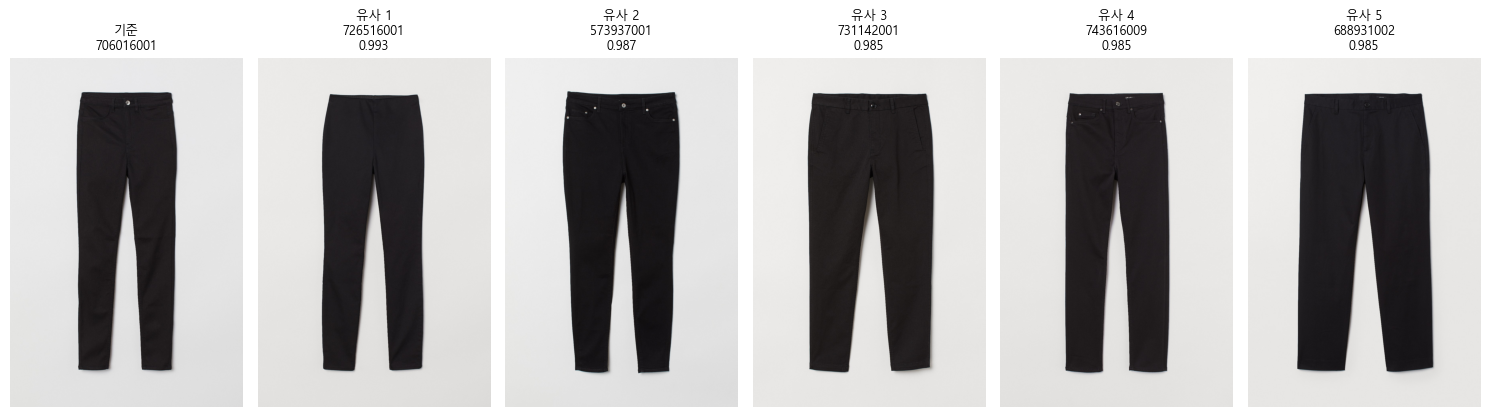

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

IMAGE_DIR = '../Data Folder/H&M dataset/images'

def show_similar(query_id, top_n=5):
    query_vec = embeddings[query_id]
    ids = np.array(list(embeddings.keys()))
    vecs = np.stack([embeddings[i] for i in ids])
    sims = vecs @ query_vec / (np.linalg.norm(vecs, axis=1) * np.linalg.norm(query_vec) + 1e-8)
    top_idx = np.argsort(sims)[::-1][1:top_n+1]
    similar_ids = ids[top_idx]

    fig, axes = plt.subplots(1, top_n+1, figsize=(15, 4))
    
    # 기준 상품
    fname = f"0{query_id}.jpg"
    path = os.path.join(IMAGE_DIR, fname[:3], fname)
    axes[0].imshow(Image.open(path))
    axes[0].set_title(f"기준\n{query_id}", fontsize=9)
    axes[0].axis('off')
    
    # 유사 상품
    for i, sid in enumerate(similar_ids):
        fname = f"0{sid}.jpg"
        path = os.path.join(IMAGE_DIR, fname[:3], fname)
        if os.path.exists(path):
            axes[i+1].imshow(Image.open(path))
            axes[i+1].set_title(f"유사 {i+1}\n{sid}\n{sims[top_idx[i]]:.3f}", fontsize=9)
        axes[i+1].axis('off')
    
    plt.tight_layout()
    plt.show()

# 인기 상품 기준으로 바로 실행
show_similar(int(top_with_emb[0]))

In [ ]:
import shutil

SAVE_DIR = '../Data Folder/clip_similar_examples'
os.makedirs(SAVE_DIR, exist_ok=True)

for sid in [706016001, 726516001]:
    filename = f"0{sid}.jpg"
    folder = filename[:3]
    src = os.path.join('../Data Folder/H&M dataset/images', folder, filename)
    dst = os.path.join(SAVE_DIR, filename)
    shutil.copy(src, dst)
    print(f"✅ 저장: {dst}")

✅ 저장: ../Data Folder/clip_similar_examples\0706016001.jpg
✅ 저장: ../Data Folder/clip_similar_examples\0726516001.jpg


In [ ]:
# articles 카테고리 정보 merge
articles_simple = articles[['article_id', 'prod_name', 'product_group_name']].copy()
articles_simple['article_id'] = articles_simple['article_id'].astype(str)

query_id = 706016001
query_vec = embeddings[query_id]

ids = np.array(list(embeddings.keys()))
vecs = np.stack([embeddings[i] for i in ids])
sims = vecs @ query_vec / (np.linalg.norm(vecs, axis=1) * np.linalg.norm(query_vec) + 1e-8)

# 상위 200개에서 다른 카테고리 찾기
top_idx = np.argsort(sims)[::-1][1:200]
top_ids = ids[top_idx]

# 카테고리 붙이기
top_df = pd.DataFrame({'article_id': top_ids.astype(str), 'similarity': sims[top_idx]})
top_df = top_df.merge(articles_simple, on='article_id', how='left')

# 기준 상품 카테고리
query_cat = articles_simple[articles_simple['article_id'] == str(query_id)]['product_group_name'].values[0]
print(f"기준 카테고리: {query_cat}")

# 다른 카테고리만 필터
diff_cat = top_df[top_df['product_group_name'] != query_cat]
print(diff_cat[['article_id', 'prod_name', 'product_group_name', 'similarity']].head(10))

기준 카테고리: 6
    article_id                 prod_name  product_group_name  similarity
103  701113001  Glacier baselayer tights                  16    0.977208


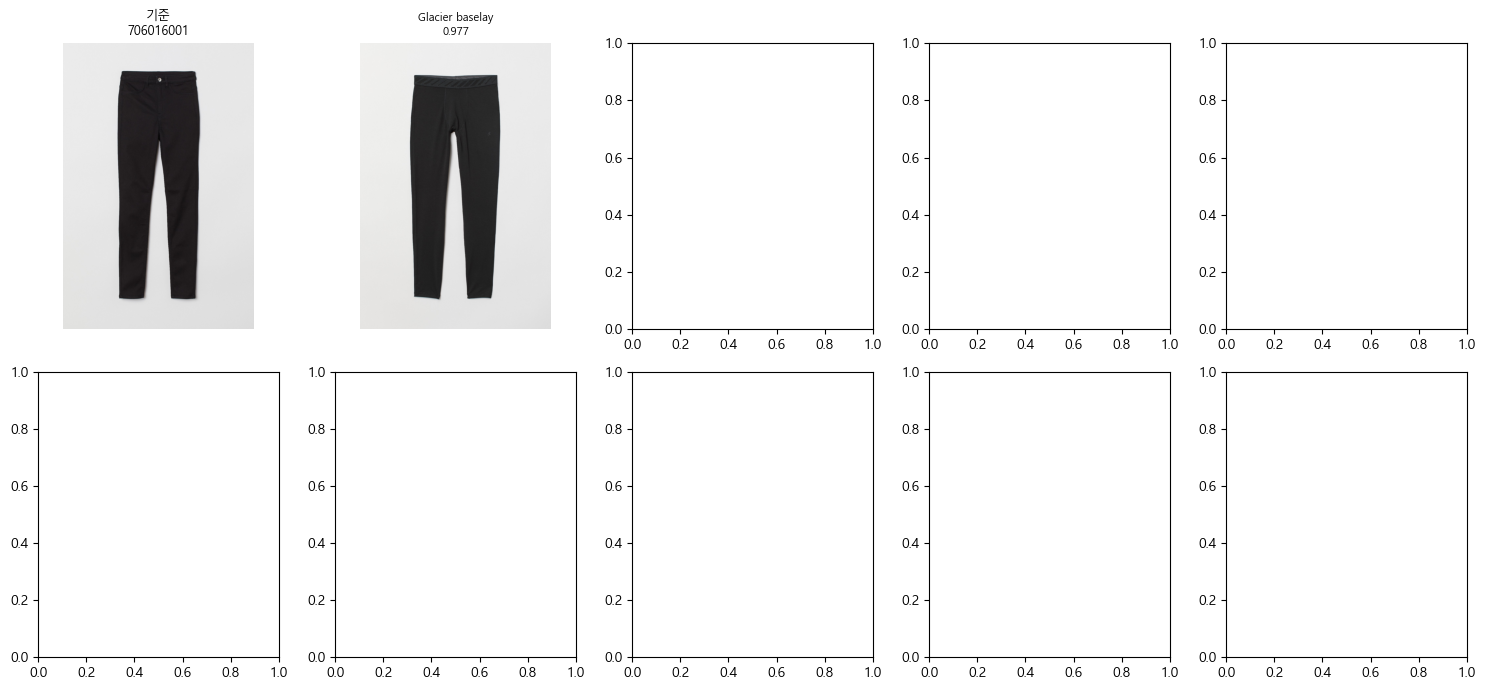

In [33]:
# 다른 카테고리 상위 10개 이미지로 바로 띄우기
diff_ids = diff_cat['article_id'].astype(int).tolist()[:10]

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.flatten()

# 기준 상품
fname = f"0{query_id}.jpg"
path = os.path.join('../Data Folder/H&M dataset/images', fname[:3], fname)
axes[0].imshow(Image.open(path))
axes[0].set_title(f"기준\n{query_id}", fontsize=9)
axes[0].axis('off')

for i, sid in enumerate(diff_ids[:9]):
    fname = f"0{sid}.jpg"
    path = os.path.join('../Data Folder/H&M dataset/images', fname[:3], fname)
    if os.path.exists(path):
        axes[i+1].imshow(Image.open(path))
        sim = diff_cat[diff_cat['article_id']==str(sid)]['similarity'].values[0]
        name = diff_cat[diff_cat['article_id']==str(sid)]['prod_name'].values[0]
        axes[i+1].set_title(f"{name[:15]}\n{sim:.3f}", fontsize=8)
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

In [34]:
import shutil

SAVE_DIR = '../Data Folder/clip_similar_examples'
os.makedirs(SAVE_DIR, exist_ok=True)

for sid in [706016001, 701113001]:
    filename = f"0{sid}.jpg"
    folder = filename[:3]
    src = os.path.join('../Data Folder/H&M dataset/images', folder, filename)
    dst = os.path.join(SAVE_DIR, filename)
    shutil.copy(src, dst)
    print(f"✅ 저장: {dst}")

✅ 저장: ../Data Folder/clip_similar_examples\0706016001.jpg
✅ 저장: ../Data Folder/clip_similar_examples\0701113001.jpg


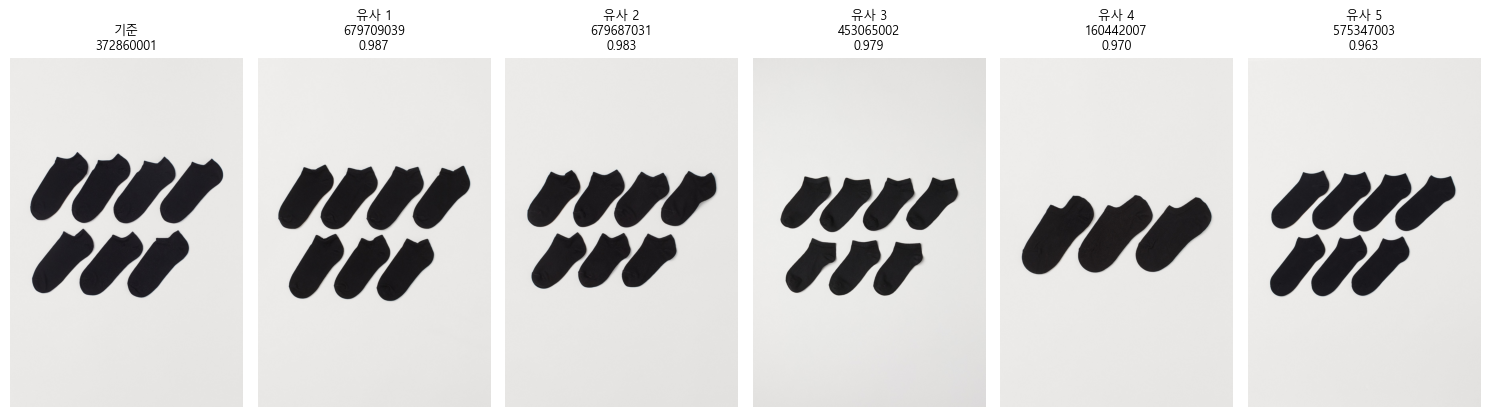

In [35]:
# 상위 거래 상품 중 다른 거 써보기
show_similar(int(top_with_emb[2]))  # 3번째 인기 상품으로

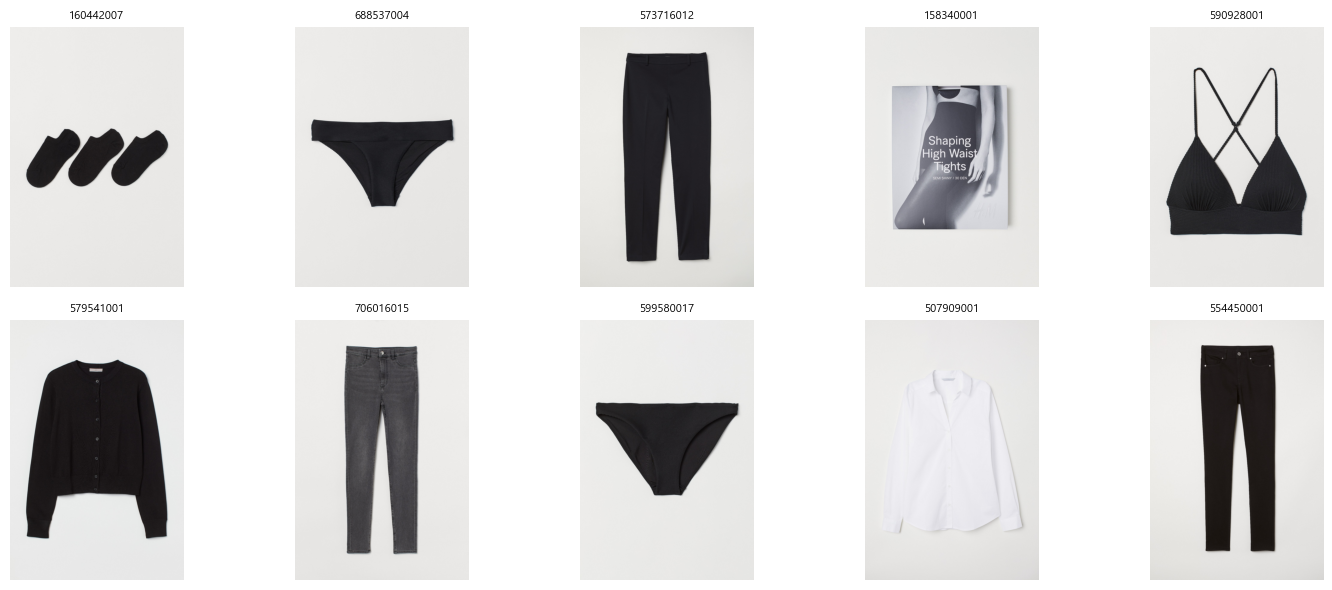

In [36]:
# 50번째 이후 인기 상품들 훑어보기
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, sid_str in enumerate(top_with_emb[20:30]):
    sid = int(sid_str)
    fname = f"0{sid}.jpg"
    path = os.path.join('../Data Folder/H&M dataset/images', fname[:3], fname)
    if os.path.exists(path):
        axes[i].imshow(Image.open(path))
        axes[i].set_title(f"{sid}", fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

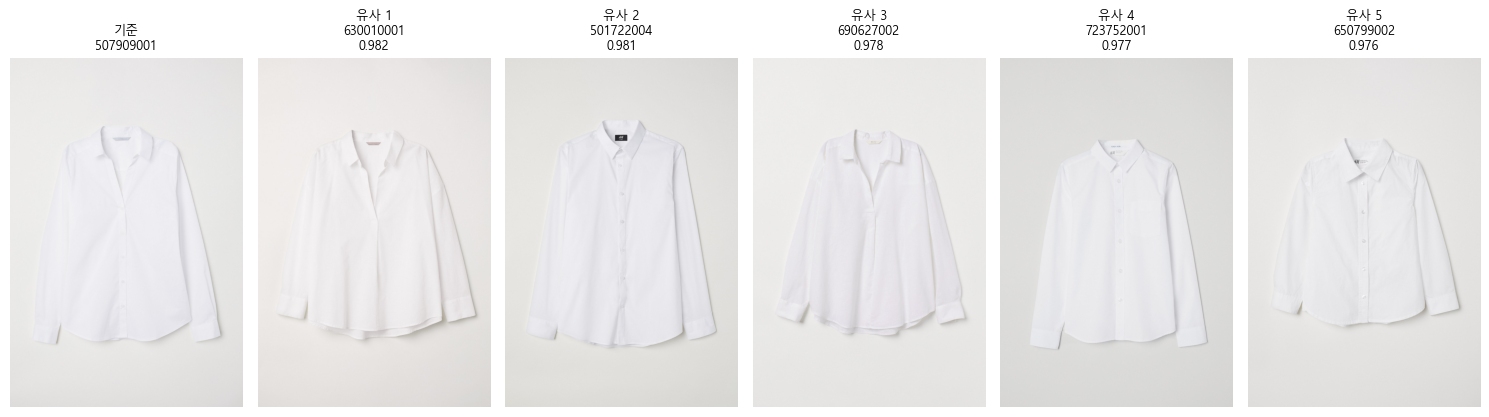

In [37]:
show_similar(507909001)

In [38]:
import shutil
SAVE_DIR = '../Data Folder/clip_similar_examples'
os.makedirs(SAVE_DIR, exist_ok=True)

for sid in [507909001, 630010001]:
    filename = f"0{sid}.jpg"
    folder = filename[:3]
    src = os.path.join('../Data Folder/H&M dataset/images', folder, filename)
    dst = os.path.join(SAVE_DIR, filename)
    shutil.copy(src, dst)
    print(f"✅ 저장: {dst}")

✅ 저장: ../Data Folder/clip_similar_examples\0507909001.jpg
✅ 저장: ../Data Folder/clip_similar_examples\0630010001.jpg


In [39]:
# gnn_customer_clusters.csv 로드
clusters = pd.read_csv('../Data Folder/gnn_customer_clusters.csv')
transactions = pd.read_parquet('../Data Folder/H&M dataset/H&m parquet dataset/transactions.parquet')
transactions['article_id'] = transactions['article_id'].astype(str)
articles = pd.read_parquet('../Data Folder/H&M dataset/H&m parquet dataset/articles.parquet')
articles['article_id'] = articles['article_id'].astype(str)

# 군집별 top3 상품 뽑기
merged = transactions.merge(clusters, on='customer_id', how='left')
merged = merged.merge(articles[['article_id', 'prod_name']], on='article_id', how='left')

for cluster_id in sorted(merged['cluster_label'].dropna().unique()):
    top3 = (merged[merged['cluster_label'] == cluster_id]
            .groupby(['article_id', 'prod_name'])
            .size()
            .sort_values(ascending=False)
            .head(3)
            .reset_index())
    print(f"\n=== Cluster {int(cluster_id)} ===")
    print(top3[['article_id', 'prod_name', 0]].to_string())


=== Cluster 0 ===
Empty DataFrame
Columns: [article_id, prod_name, 0]
Index: []

=== Cluster 1 ===
Empty DataFrame
Columns: [article_id, prod_name, 0]
Index: []

=== Cluster 2 ===
Empty DataFrame
Columns: [article_id, prod_name, 0]
Index: []

=== Cluster 3 ===
Empty DataFrame
Columns: [article_id, prod_name, 0]
Index: []


In [40]:
print(clusters.columns.tolist())
print(clusters.head(3))
print(merged.columns.tolist())

['customer_id', 'cluster_label']
                                         customer_id  cluster_label
0  00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...              0
1  0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...              2
2  000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...              0
['t_dat', 'customer_id', 'article_id', 'price', 'sales_channel_id', 'price_eur', 'days_from_latest', 'time_weight', 'covid_period', 'cluster_label', 'prod_name']
